In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("D:\\Data-Analytics-Internship\\datasets\\customer_support_tickets.csv")
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [54]:
missing_values_before = df.isnull().sum().sum()

print(missing_values_before)
duplicates_before = df.duplicated().sum()

print(duplicates_before)
summary = pd.DataFrame({
    'Metric': ['missing_values_before', 'duplicates_before'],
    'Value': [missing_values_before, duplicates_before]
})

summary.to_csv("cleaning_summary.csv", index=False)

19919
0


In [55]:
df.ffill(inplace=True)
df.isnull().sum()

Ticket ID                       0
Customer Name                   0
Customer Email                  0
Customer Age                    0
Customer Gender                 0
Product Purchased               0
Date of Purchase                0
Ticket Type                     0
Ticket Subject                  0
Ticket Description              0
Ticket Status                   0
Resolution                      2
Ticket Priority                 0
Ticket Channel                  0
First Response Time             0
Time to Resolution              2
Customer Satisfaction Rating    2
dtype: int64

In [56]:
df = df.drop_duplicates()
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
print(df['Date of Purchase'].dtype)

datetime64[us]


In [57]:
#Automating cleaning process
def clean_data(df):

    df.drop_duplicates(inplace=True)

    df.bfill(inplace=True)

    return df

df = clean_data(df)

In [58]:
report = df.describe()

print(report)

         Ticket ID  Customer Age            Date of Purchase  \
count  8469.000000   8469.000000                        8469   
mean   4235.000000     44.026804  2020-12-30 01:35:13.071200   
min       1.000000     18.000000         2020-01-01 00:00:00   
25%    2118.000000     31.000000         2020-07-02 00:00:00   
50%    4235.000000     44.000000         2020-12-31 00:00:00   
75%    6352.000000     57.000000         2021-07-01 00:00:00   
max    8469.000000     70.000000         2021-12-30 00:00:00   
std    2444.934048     15.296112                         NaN   

       Customer Satisfaction Rating  
count                   8469.000000  
mean                       2.974731  
min                        1.000000  
25%                        2.000000  
50%                        3.000000  
75%                        4.000000  
max                        5.000000  
std                        1.398958  


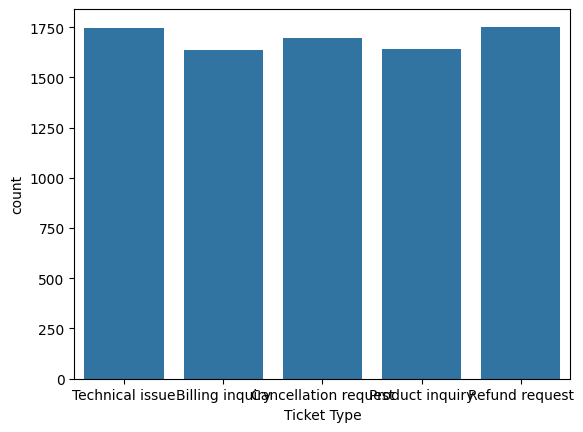

In [59]:
sns.countplot(x='Ticket Type', data=df)
plt.show()

In [60]:
df.to_csv("cleaned_data.csv", index=False)